Lately, I often hear my peers talk about how the housing market—especially in big cities like Copenhagen, is becoming increasingly difficult for young people and first-time buyers. This concern is also reflected in the media, and it was one of the key topics in the recent 2025 municipal election (ref). Many feel that we do not have the same opportunities as our parents’ generation.

In this article, I take a data-driven approach to investigate this sentiment. I will examine how the housing market has evolved since 1992, using the annual average price per square meter, and evaluate whether it has indeed become less affordable to buy property with an average salary. I will also explore how these trends differ across municipalities in Denmark.

The first step is to look at the overall development of housing prices compared to average incomes. The chart below illustrates how property prices have grown much faster than wages over the past three decades, highlighting the increasing challenge of affordability.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

income_df = pd.read_csv('data/cleaned/income.csv')
house_price_df = pd.read_csv('data/cleaned/ejendomsdata.csv')

long_df = house_price_df.melt(
    id_vars="kommune",
    var_name="quarter",
    value_name="price"
)

long_df["year"] = long_df["quarter"].str[:4].astype(int)
long_df["q"] = long_df["quarter"].str[-1].astype(int)
long_df["time"] = long_df["year"] + (long_df["q"] - 1) / 4

avg_prices_yearly = (
    long_df
    .groupby("year")["price"]
    .mean()
    .reset_index()
    .rename(columns={"price": "avg_price"})
)

avg_income_yearly = (
    income_df
    .groupby("år", as_index=False)["income"]
    .mean()
    .rename(columns={"år": "year", "income": "avg_income"})
)

plot_df = avg_prices_yearly.merge(
    avg_income_yearly,
    on="year",
    how="inner"
)

base_year = 1992

base_price = plot_df.loc[plot_df["year"] == base_year, "avg_price"].iloc[0]
base_income = plot_df.loc[plot_df["year"] == base_year, "avg_income"].iloc[0]

plot_df["price_change_pct"] = (plot_df["avg_price"] / base_price - 1) * 100
plot_df["income_change_pct"] = (plot_df["avg_income"] / base_income - 1) * 100



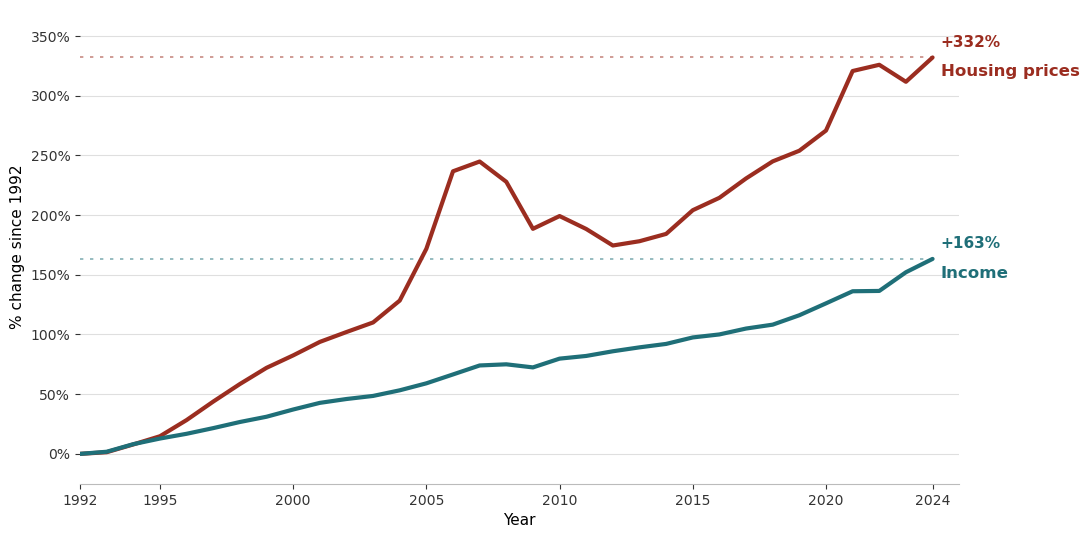

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Colors
price_color = "#9B2D20"    
income_color = "#1F6F78"   
grid_color = "#D8D8D8"
text_color = "#222222"
muted_text = "#666666"

fig, ax = plt.subplots(figsize=(11, 6.3))


ax.plot(
    plot_df["year"],
    plot_df["price_change_pct"],
    color=price_color,
    linewidth=3,
    label="Average square meter price",
    solid_capstyle="round",
    zorder=3
)

ax.plot(
    plot_df["year"],
    plot_df["income_change_pct"],
    color=income_color,
    linewidth=3,
    label="Average income before tax",
    solid_capstyle="round",
    zorder=3
)

# Direct line labels and endpoint values
latest_year = plot_df["year"].max()
latest = plot_df.loc[plot_df["year"] == latest_year].iloc[0]

price_end = latest["price_change_pct"]
income_end = latest["income_change_pct"]

# Horizontal endpoint reference lines
ax.hlines(
    y=price_end,
    xmin=plot_df["year"].min(),
    xmax=latest_year,
    color=price_color,
    linewidth=1.2,
    linestyle=(0, (2, 4)),
    alpha=0.55,
    zorder=1
)

ax.hlines(
    y=income_end,
    xmin=plot_df["year"].min(),
    xmax=latest_year,
    color=income_color,
    linewidth=1.2,
    linestyle=(0, (2, 4)),
    alpha=0.55,
    zorder=1
)

# Value labels
ax.text(
    latest_year + 0.3,
    price_end + 13,
    f"+{price_end:.0f}%",
    color=price_color,
    fontsize=11,
    fontweight="bold",
    va="center"
)

ax.text(
    latest_year + 0.3,
    income_end + 13,
    f"+{income_end:.0f}%",
    color=income_color,
    fontsize=11,
    fontweight="bold",
    va="center"
)

# Series labels
ax.text(
    latest_year + 0.3,
    price_end - 12,
    "Housing prices",
    color=price_color,
    fontsize=12,
    fontweight="bold",
    va="center"
)

ax.text(
    latest_year + 0.3,
    income_end - 12,
    "Income",
    color=income_color,
    fontsize=12,
    fontweight="bold",
    va="center"
)

# Axes
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("% change since 1992", fontsize=11)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

ax.set_xlim(plot_df["year"].min(), 2025)
ax.set_xticks([1992,1995, 2000, 2005, 2010, 2015, 2020, 2024])

ymax = max(plot_df["price_change_pct"].max(), plot_df["income_change_pct"].max())
ax.set_ylim(-25, ymax * 1.12)

# Grid and spines
ax.grid(axis="y", color=grid_color, linewidth=0.8, alpha=0.8)
ax.grid(axis="x", visible=False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#BBBBBB")
ax.tick_params(axis="both", labelsize=10, colors="#333333")

ax.legend().remove()

plt.tight_layout(rect=[0, 0.05, 1, 0.92])


plt.savefig("output/price_income_trends.png", dpi=300)
plt.show()



The time-series above shows that the housing market becoming less accessible is not just a feeling, but reflects a real trend. It tells a compelling story of the increasing gap between average housing prices and average incomes over the last 34 years. You can also clearly see the impact of the financial crisis: housing prices skyrocketed leading up to the 2008 boom, while incomes remained relatively stable during the same period. This visualization highlights both the long-term trend and the specific moments when the market experienced dramatic changes.